<a href="https://colab.research.google.com/github/Polyanat59/Trab_preparacao_de_dados/blob/main/preparacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
sns.set(style="whitegrid")

In [6]:
lojas = []
for i in range(1, 5):
    df = pd.read_csv(f"loja_{i}.csv")
    df["loja"] = f"Loja {i}"
    lojas.append(df)

# Unificar
dados = pd.concat(lojas, ignore_index=True)


In [8]:
# Padronizar colunas
dados.columns = (
    dados.columns.str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("ã", "a")
    .str.replace("ç", "c")
    .str.replace("é", "e")
)
print("Colunas ", dados.columns.tolist())

Colunas  ['produto', 'categoria_do_produto', 'preco', 'frete', 'data_da_compra', 'vendedor', 'local_da_compra', 'avaliacao_da_compra', 'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon', 'loja']


In [9]:
# converte as colunas numericas
numeric_cols = ["preco", "frete", "avaliacao_da_compra"]
for col in numeric_cols:
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

In [10]:
# Remover linhas sem preco/frete
dados = dados.dropna(subset=["preco", "frete"])

In [11]:
print(dados.columns.tolist())


['produto', 'categoria_do_produto', 'preco', 'frete', 'data_da_compra', 'vendedor', 'local_da_compra', 'avaliacao_da_compra', 'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon', 'loja']


In [12]:
dados.head()

,produto,categoria_do_produto,preco,frete,data_da_compra,vendedor,local_da_compra,avaliacao_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [13]:
#Coluna faturamento
dados["faturamento"] = dados["preco"] + dados["frete"]
dados.head()

,produto,categoria_do_produto,preco,frete,data_da_compra,vendedor,local_da_compra,avaliacao_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,loja,faturamento
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1,228.329790
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1,267.584305
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1,300.772681
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1,1064.657344
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1,473.954689


Top 5 Categorias por Faturamento Total:
categoria_do_produto
eletronicos              R$ 2,332,048.08
eletrodomesticos         R$ 1,860,198.66
moveis                   R$ 1,064,149.77
instrumentos musicais      R$ 489,701.48
esporte e lazer            R$ 200,891.94
Name: faturamento, dtype: object


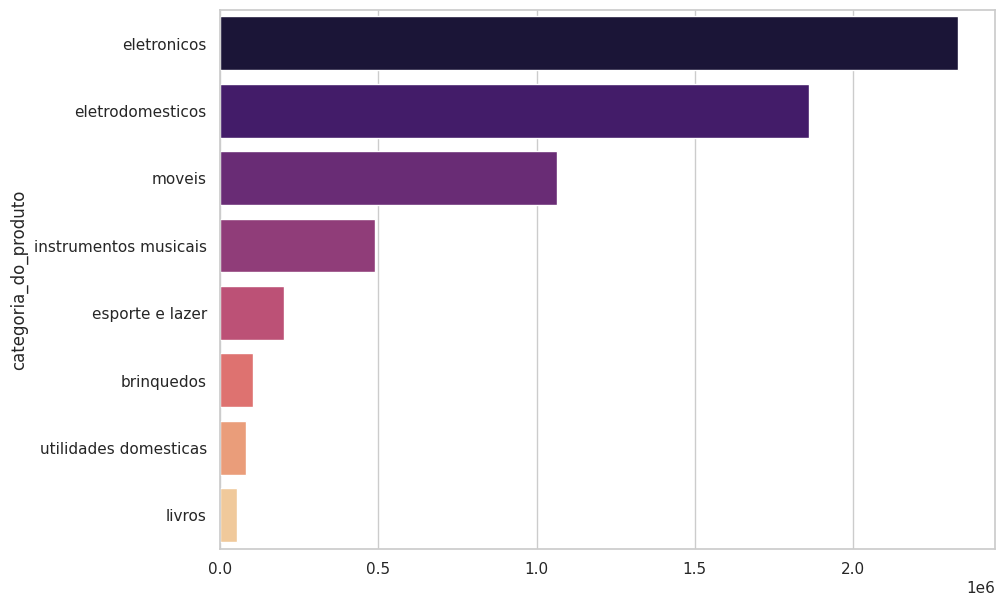

In [14]:
# Categorias mais vendidads
if "faturamento" in dados.columns and "categoria_do_produto" in dados.columns:
    cat_fat_total = dados.groupby("categoria_do_produto")["faturamento"].sum().sort_values(ascending=False)

    print("Top 5 Categorias por Faturamento Total:")
    print(cat_fat_total.head(5).apply(lambda x: f"R$ {x:,.2f}"))

    plt.figure(figsize=(10, 7))
    sns.barplot(
        x=cat_fat_total.head(10).values,
        y=cat_fat_total.head(10).index,
        hue=cat_fat_total.head(10).index,
        palette="magma",
        legend=False
    )

In [15]:
numericas = ["preco", "frete", "avaliacao_da_compra", "faturamento"]
resumo = dados[numericas].describe().round(2)
print("\nResumo estatístico:")
print(resumo)


Resumo estatístico:
         preco    frete  avaliacao_da_compra  faturamento
count  9435.00  9435.00              9435.00      9435.00
mean    622.31    33.17                 4.01       655.48
std     787.09    41.97                 1.39       828.98
min      10.07     0.00                 1.00        10.07
25%      73.61     4.01                 3.00        77.57
50%     295.35    15.65                 5.00       310.76
75%     884.40    46.59                 5.00       931.47
max    3969.38   216.71                 5.00      4181.05


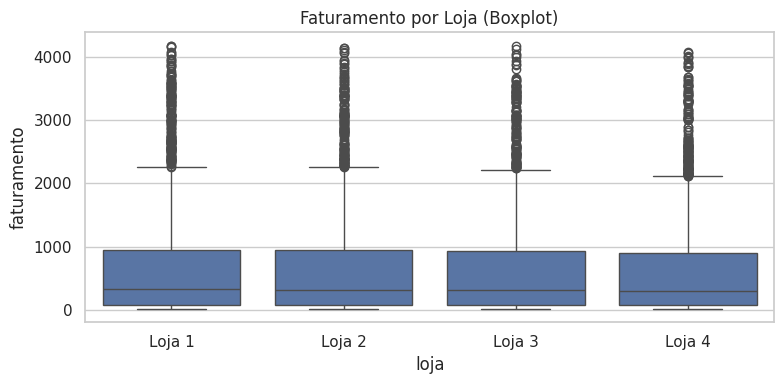

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x="loja", y="faturamento", data=dados)
plt.title("Faturamento por Loja (Boxplot)")
plt.tight_layout()
plt.show()

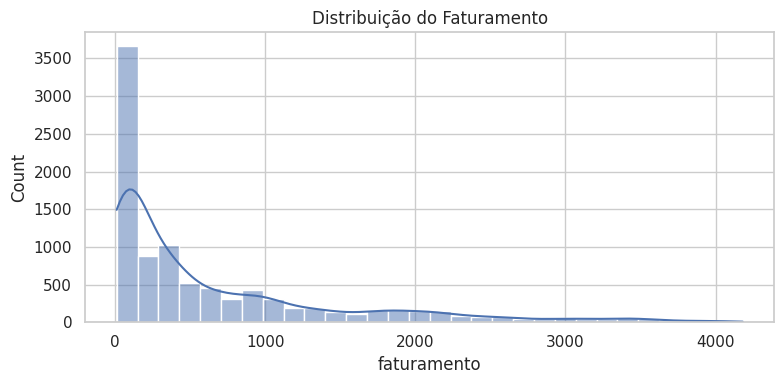

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(dados["faturamento"], bins=30, kde=True)
plt.title("Distribuição do Faturamento")
plt.tight_layout()
plt.show()

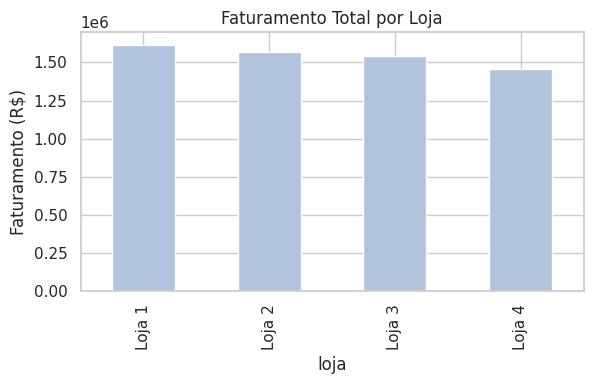

In [18]:
fat = dados.groupby("loja")["faturamento"].sum()
plt.figure(figsize=(6,4))
fat.plot(kind="bar", color="lightsteelblue")
plt.title("Faturamento Total por Loja")
plt.ylabel("Faturamento (R$)")
plt.tight_layout()
plt.show()